In [44]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
import datetime
sys.path.append('../..')
from src import train, utils
from src import calculus as calc
import src.data.cube_domain as cb
import src.models.moe_nonseparate as mn

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RE = 1000
NU = 1 / RE
T_MAX = 1
L_BOUNDS = (0, 0)
U_BOUNDS = (1, 1)
L=1
W = 1.0

In [46]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
def h(x):
    safe_x = torch.clamp(x, min=1e-6)
    return torch.where(x > 0, torch.exp(-1 / safe_x), torch.zeros_like(x))

def B(x, r_1=0.2, r_2=0.5):
    return h(r_2 - x) / (h(r_2 - x) + h(x - r_1))

In [48]:
from math import pi

def g_N_poly(x):
    return torch.column_stack((torch.sin(pi * x[:, 0:1])**2 * x[:, 1:2], torch.zeros_like(x[:, 0:2])))

def g_N(x):
    return torch.column_stack((B(torch.abs(x[:, 0:1] - 0.5)) * x[:, 1:2]**2, torch.zeros_like(x[:, 0:2])))
 
def f(x):
    y = (x[:, 0:1] * (x[:, 0:1] - 1) * x[:, 1:2] * (x[:, 1:2] - 1)).repeat(1, 2)
    return torch.column_stack((y, torch.ones_like(x[:, 0:1])))

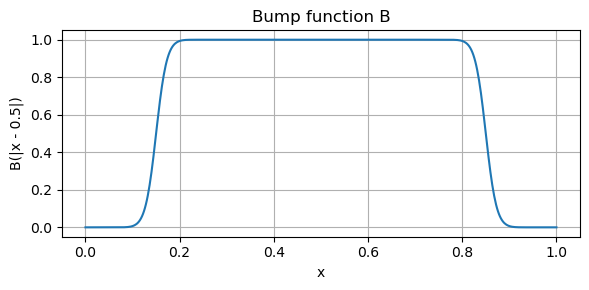

In [49]:
import matplotlib.pyplot as plt
import numpy as np

x_np = np.linspace(0, 1, 500)
x_t = torch.tensor(x_np, dtype=torch.float32)
b_vals = B(torch.abs(x_t - 0.5)).numpy()

plt.figure(figsize=(6, 3))
plt.plot(x_np, b_vals)
plt.xlabel("x")
plt.ylabel("B(|x - 0.5|)")
plt.title("Bump function B")
plt.grid(True)
plt.tight_layout()
plt.show()


In [50]:
model_expt_ctx = mn.MoECtx(
    input_dim=2,
    output_dims=[1, 1, 1],
    hidden_layers_per_output=[[16, 16, 16], [16, 16, 16], [16, 16, 16]],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hard_enforce=True,
    discontinuous_per_layer=[False, False, False],
    constraint_functions=(g_N_poly, f)
)


model_ept = mn.MoEModel(model_expt_ctx).to(device)
optim_ept = torch.optim.Adam(model_ept.parameters(), lr=1e-3)
scheduler_ept = ReduceLROnPlateau(optim_ept, factor=0.5, patience=2_000, min_lr=1e-5)

In [51]:
# NOTE: input is assumed to have requires_grad=True
def pde_res(u: torch.Tensor, v:torch.Tensor, p: torch.Tensor, x: torch.Tensor):    
    u_grad = grad(u, x, torch.ones_like(u), create_graph=True)[0]
    v_grad = grad(v, x, torch.ones_like(v), create_graph=True)[0]
    u_x, u_y = u_grad[:, 0:1], u_grad[:, 1:2]
    v_x, v_y = v_grad[:, 0:1], v_grad[:, 1:2]
    
    u_xx = grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, x, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
    v_xx = grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0][:, 0:1]
    v_yy = grad(v_y, x, torch.ones_like(v_y), create_graph=True)[0][:, 1:2]
    
    p_grad = grad(p, x, torch.ones_like(p), create_graph=True)[0]
    p_x, p_y = p_grad[:, 0:1], p_grad[:, 1:2]
    
    res_a = u * u_x + v * u_y + p_x - W * NU * (u_xx + u_yy)
    res_b = u * v_x + v * v_y + p_y - W * NU * (v_xx + v_yy)
    res_ct = u_x + v_y
        
    return res_a, res_b, res_ct


def pde_loss_uvp(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_pts = domain.interior.clone().to(device).requires_grad_(True)
    model_out = model(pde_pts)
    u, v, p = model_out[:, 0:1], model_out[:, 1:2], model_out[:, 2:3]
    pde_res_a, pde_res_b, pde_res_ct  = pde_res(u, v, p, pde_pts)
    pde_loss = torch.mean((pde_res_a**2 + pde_res_b**2))
    cty_loss = torch.mean((2 - pde_pts[:, 1:2])*pde_res_ct**2)
    
    return [pde_loss, cty_loss]


In [52]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    device=device,
    int_sampling='Latin', 
    N_int=10_000,
    N_sides=[(0, 0), (0, 0), (0, 0)],
)

domain = cb.CubeDomain(domain_ctx)

In [53]:
train_uv_ctx = train.TrainingContext(
    model=model_ept,
    optimizer=optim_ept,
    domain=domain,
    loss_fn=pde_loss_uvp,
    resample=True,
    epochs=120_000,
    monitor_gradient=True,
    monitor_lr=True,
)


cont_only_loss, cont_only_loss_comp, grad_norms_per_loss = train.simple_train(train_uv_ctx)


Loss at epoch 1 is: 2.4119627475738525. Total gradient norm: 0.42747169329483814 Component 0 grad norm: 0.08856658568796309 Component 1 grad norm: 0.3523858041350363 Current learing rate: 0.001 
Loss at epoch 100 is: 1.3983752727508545. Total gradient norm: 0.5818871210308362 Component 0 grad norm: 0.13177583670956802 Component 1 grad norm: 0.5164154846241646 Current learing rate: 0.001 
Loss at epoch 200 is: 0.9390861392021179. Total gradient norm: 0.43271001390568214 Component 0 grad norm: 0.0928993193344681 Component 1 grad norm: 0.4056426035942073 Current learing rate: 0.001 
Loss at epoch 300 is: 0.7346234321594238. Total gradient norm: 0.28717981594771963 Component 0 grad norm: 0.07610472078304756 Component 1 grad norm: 0.27277806594333187 Current learing rate: 0.001 
Loss at epoch 400 is: 0.6243228316307068. Total gradient norm: 0.1948905069420386 Component 0 grad norm: 0.07300752249428287 Component 1 grad norm: 0.18165374370720913 Current learing rate: 0.001 
Loss at epoch 500 

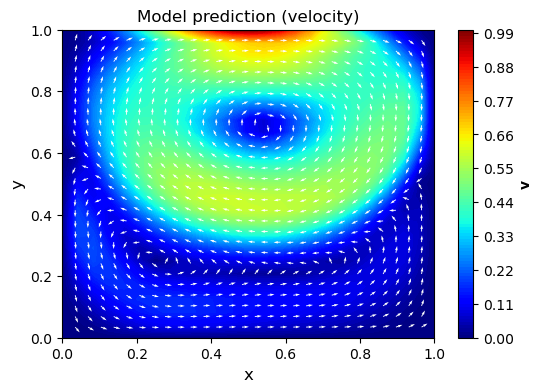

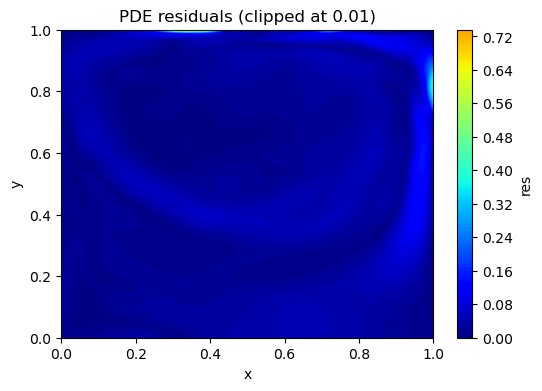

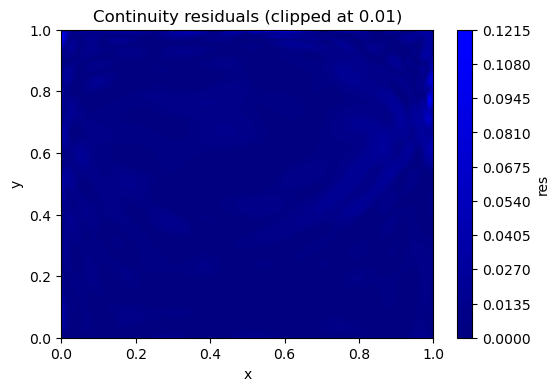

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/cavity_flow/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


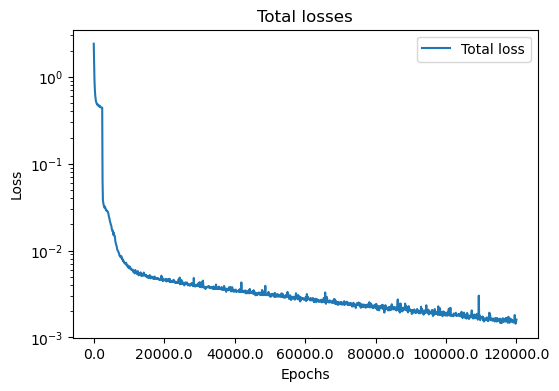

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/cavity_flow/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


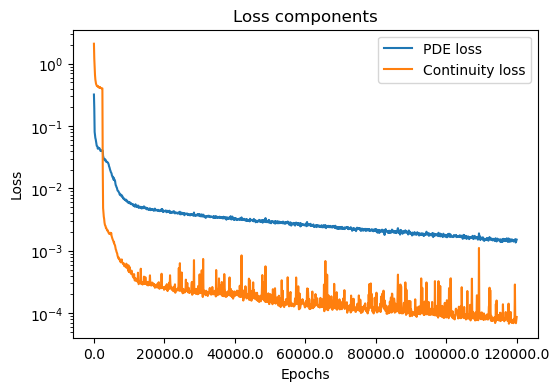

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/cavity_flow/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


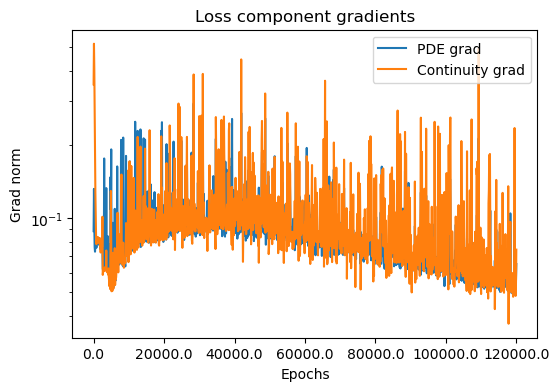

In [54]:
# define plot context
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    function_names = [r'$\mathbf{v}$'],
    titles= ['Model prediction (velocity)'],
    device=device,
    vmin=0,
    vmax=1,
    patches=[],
    N = 100
)


def velocity(x: torch.Tensor) -> torch.Tensor:    
    return model_ept(x)[:, 0:2]

utils.plot_vector_field_2d([velocity], plot_ctx, N=25, n_heigth=30, n_width=30)


def res_helper(x):
    x = x.requires_grad_(True)
    uvp = model_ept(x)
    
    u, v, p = uvp[:, 0:1], uvp[:, 1:2], uvp[:, 2:3]
    res_a, res_b, res_ct = pde_res(u, v, p, x)

    res = torch.sqrt(res_a**2 + res_b**2)
    
    return torch.clamp(res, 0.0, 1), torch.clamp(torch.abs(res_ct), 0.0, 1)


plot_ctx.titles = ['PDE residuals (clipped at 0.01)']
plot_ctx.function_names = ['res']
plot_ctx.vmax = 1
utils.plot_function_on_2d_cube([lambda x : res_helper(x)[0]], plot_ctx)

plot_ctx.titles = ['Continuity residuals (clipped at 0.01)']
utils.plot_function_on_2d_cube([lambda x : res_helper(x)[1]], plot_ctx)


plot_ctx.x_label = "Epochs"
plot_ctx.y_label = "Loss"

plot_ctx.titles = ["Total losses"]
utils.plot_loss_values({"Total loss": cont_only_loss}, plot_ctx)

plot_ctx.titles = ["Loss components"]
utils.plot_loss_values({r"PDE loss": cont_only_loss_comp[0], r"Continuity loss": cont_only_loss_comp[1]}, plot_ctx)


plot_ctx.titles = ["Loss component gradients"]
plot_ctx.x_label = "Epochs"
plot_ctx.y_label = "Grad norm"
utils.plot_loss_values({r"PDE grad": grad_norms_per_loss[0], r"Continuity grad": grad_norms_per_loss[1]}, plot_ctx)

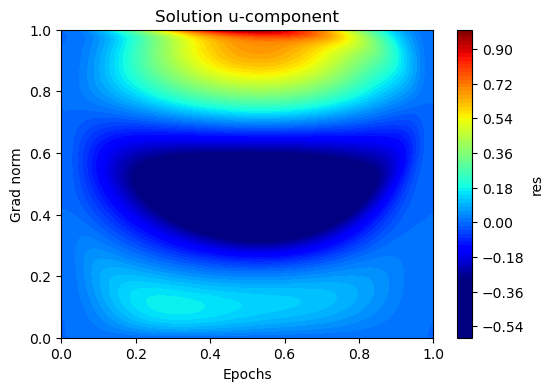

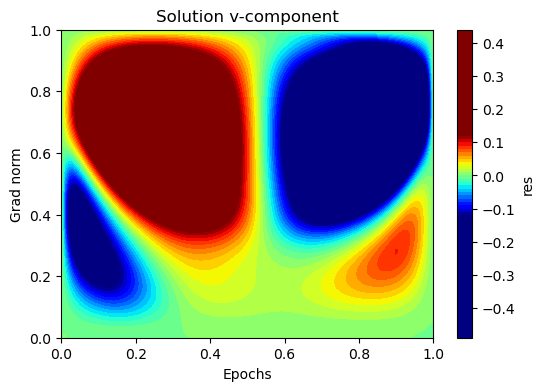

In [55]:
plot_ctx.vmax = 1
plot_ctx.vmin=-0.3

plot_ctx.titles = ['Solution u-component']
utils.plot_function_on_2d_cube([lambda x : model_ept(x)[:, 0]], plot_ctx)

plot_ctx.titles = ['Solution v-component']
plot_ctx.vmax = 0.12
plot_ctx.vmin=-0.12
utils.plot_function_on_2d_cube([lambda x : model_ept(x)[:, 1]], plot_ctx)

In [56]:
import h5py
import numpy as np

with h5py.File('./cavity_solution.h5', 'r') as f:
    x_ref  = torch.tensor(f['x'][:],  dtype=torch.float32)
    y_ref  = torch.tensor(f['y'][:],  dtype=torch.float32)
    ux_ref = torch.tensor(f['ux'][:], dtype=torch.float32)
    uy_ref = torch.tensor(f['uy'][:], dtype=torch.float32)
    p_ref  = torch.tensor(f['p'][:],  dtype=torch.float32)

print(f"Loaded {x_ref.shape[0]} reference points")
print(f"  x:  {x_ref.shape}, ux: {ux_ref.shape}, uy: {uy_ref.shape}, p: {p_ref.shape}")


Loaded 10000 reference points
  x:  torch.Size([10000]), ux: torch.Size([10000]), uy: torch.Size([10000]), p: torch.Size([10000])


In [57]:
# Build input tensor from reference coordinates and evaluate PINN
xy_ref = torch.stack([x_ref, y_ref], dim=1).to(device)

model_ept.eval()
with torch.no_grad():
    uvp_pred = model_ept(xy_ref)

ux_pred = uvp_pred[:, 0].cpu()
uy_pred = uvp_pred[:, 1].cpu()

# Absolute differences
diff_ux = torch.abs(ux_pred - ux_ref)
diff_uy = torch.abs(uy_pred - uy_ref)

print(f"{'Field':<6}  {'Mean |err|':>12}  {'Max |err|':>12}  {'L2 err':>12}")
print("-" * 48)
for name, diff in [("ux", diff_ux), ("uy", diff_uy)]:
    print(f"{name:<6}  {diff.mean().item():>12.6f}  {diff.max().item():>12.6f}  {diff.norm().item():>12.6f}")


Field     Mean |err|     Max |err|        L2 err
------------------------------------------------
ux          0.163478      0.491012     20.996649
uy          0.102122      0.347407     13.055653


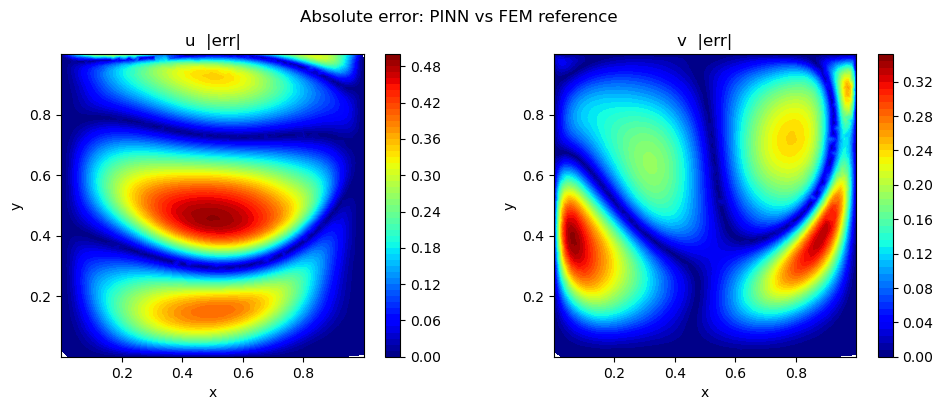

In [58]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

x_np = x_ref.numpy()
y_np = y_ref.numpy()
triang = mtri.Triangulation(x_np, y_np)

fields = [("u  |err|", diff_ux), ("v  |err|", diff_uy)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (title, diff) in zip(axes, fields):
    tcf = ax.tricontourf(triang, diff.numpy(), levels=50, cmap='jet')
    fig.colorbar(tcf, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect('equal')

plt.suptitle("Absolute error: PINN vs FEM reference")
plt.tight_layout()
plt.show()
